In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import params

params.configure_renku_cuda()
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Training configuration - modify these parameters as needed
PARAMS = params.Params(
    VARIABLE='tmax',
    DATA_YEAR_START=2014,  # Set to None for full dataset
    N_EPOCHS=30,
    N_FOLDS=5,
    TRIAL_NAME='final-2014-30e-5f-ablation-seasonal-all',
    RUN_TYPE='cloud' if params.is_renku() else 'local',
    # Trialed on Renku, 1 of 5 folds, avg 5 epochs
    # | Batch size | Epoch duration |
    # | ---------- | -------------- |
    # | 14+        | out-of-memory  |
    # | 13         | 1min 9s        |
    # | 12         | 1min 15s       |
    # | 11         | 1min 10s       |
    # | 10         | 1min 0s        |
    # | 6-9        | 1min 1s        |
    # | 5          | 1min 2s        |
    # | 3-4        | 1min 4s        |
    # | 2          | 1min 12s       |
    # | 1          | 1min 19s       |
    BATCH_SIZE=8 if params.is_renku() else 16,
    DEVICE=device,
    SEASONAL_FEATURES=False,
    SEASONAL_FEATURES_IN_MLP=False,  # Whether to include seasonal features in elevation MLP
)

print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2014, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, SEASONAL_FEATURES=False, SEASONAL_FEATURES_IN_MLP=False, N_EPOCHS=30, BATCH_SIZE=8, LR=0.0005, PATIENCE=10, N_FOLDS=5, SEED=42, TRIAL_NAME='final-2014-30e-5f-ablation-seasonal-all', RUN_TYPE='cloud', DEVICE=device(type='cuda'), ERA5_MAX_TEMP_GLOB=None, ERA5_GEOPOTENTIAL_GLOB=None, METEO_SWISS_MAX_TEMP_GLOB=None, HI_RES_TOPOGRAPHY_ZARR_PATH=None)


In [4]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim

import datasets as ds
import model_factory
import cloud_sync
import visualization as vis
from convCNP.training.training_elev import train_elev

In [5]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

cloud_sync.sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Save data paths in params for reproducibility (used by predictions notebook)
PARAMS = PARAMS.with_data_paths(ds.build_data_paths(BASE_DATASET_DIR))

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:
dirsync finished in 0.12 seconds.
28 directories parsed, 0 files copied

Dataset sync complete.


In [6]:
# Load ERA5 input data using imported function
train_input_ds, era5_metadata, era5_grid_elevation, time_coords = ds.load_era5_data(
    PARAMS.ERA5_MAX_TEMP_GLOB,
    var_name='t2m_max',
    year_start=PARAMS.DATA_YEAR_START,
    geopotential_glob=PARAMS.ERA5_GEOPOTENTIAL_GLOB,
    geopotential_var_name='z',
    device=device
)

# Track input channels from ERA5 data and update PARAMS
PARAMS = PARAMS.with_in_channels(train_input_ds.shape[1])
print(f"IN_CHANNELS set to: {PARAMS.IN_CHANNELS}")

# Compute seasonal features from time coordinates if enabled
# These will be passed to the elevation MLP to learn season-dependent corrections
if PARAMS.SEASONAL_FEATURES_IN_MLP:
    seasonal_features = ds.compute_seasonal_features(time_coords, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}  # (time, 2) for [cos_doy, sin_doy]")
else:
    seasonal_features = None
    print("Seasonal features disabled")

Loading ERA5 data from: datasets/ERA5_Land/max_temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2014: 2014-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 3652, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m_max (Kelvin)...
Final tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([3652, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
E

In [7]:
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(PARAMS.HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32


In [8]:
# Load MeteoSwiss targets using imported function
target_x, target_y, target_topo = ds.prepare_meteoswiss_targets(
    PARAMS.METEO_SWISS_MAX_TEMP_GLOB,
    normalization_stats=era5_metadata,
    data_var='TmaxD',
    grid_elevation=era5_grid_elevation,
    hi_res_elevation=hi_res_elevation,
    hi_res_tpi=hi_res_tpi,
    convert_to_kelvin=True,
    year_start=PARAMS.DATA_YEAR_START,
    device=device
)

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TmaxD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Converting target coordinates to Swiss LV95 for hi-res DEM lookup...
  -> Interpolating hi-res DEM at target points...
  -> Interpolating ERA5 grid elevation at target points...
  -> True elevation range: [181.7, 4675.4] m
  -> Grid elevat

In [9]:
# Calculate distances using imported function
dists = ds.calculate_dists_meteoswiss(era5_metadata, target_x, device=device)
print(f"Distances shape: {dists.shape}")

Distances shape: torch.Size([88800, 29, 61])


In [10]:
params.set_seed(PARAMS.SEED)

In [11]:
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')

In [12]:
# Create output directory if it doesn't exist
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

PARAMS.save_json(output_dir / 'params.json')
ds.save_metadata_json(era5_metadata, output_dir / 'metadata.json')

train_target_ds = torch.from_numpy(target_y.values.astype(np.float32)).to(device)
print(f"train_target_ds shape: {train_target_ds.shape}, dtype: {train_target_ds.dtype}  # Expected: (time, n_points), float32")

STATS_HEADER = 'Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n'

# Loop over cross-validation folds
for fold in range(PARAMS.N_FOLDS):
    # if fold in (0, 1, 3,):
    #     # We have already these folds, do just the remaining ones
    #     print(f'Skipping fold {fold + 1}')
    #     continue
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    # Per-fold stats file so resumed training doesn't destroy previous results
    fold_stats_file = os.path.join(OUTPUT_DIR, f'stats_fold{fold}.csv')
    if not os.path.exists(fold_stats_file):
        with open(fold_stats_file, 'w') as f:
            f.write(STATS_HEADER)

    # Reset model weights and optimizer for each fold
    params.set_seed(PARAMS.SEED + fold)  # Use a different seed for each fold for robustness
    model, loss_fn, get_value_fn = model_factory.build_model(PARAMS)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    # Train the model. Note: fold splitting logic is inside train_elev
    train_elev(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        elev=target_topo,
        dists=dists,
        y_context=train_input_ds,
        y_target=train_target_ds,
        output_dir=OUTPUT_DIR,
        y_target_t=None,  # did not figure out what this does, it's not used internally in Vaughan et al's code
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE,
        stats_file=fold_stats_file,
        seasonal=seasonal_features,  # Pass seasonal features (or None if disabled)
        device=device
    )

    cloud_sync.sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)

# Merge per-fold stats into a single stats.csv
fold_csvs = [os.path.join(OUTPUT_DIR, f'stats_fold{f}.csv') for f in range(PARAMS.N_FOLDS)]
pd.concat([pd.read_csv(p) for p in fold_csvs if os.path.exists(p)]).to_csv(stats_file, index=False)

print(f'\nTraining finished for all {PARAMS.N_FOLDS} folds. Models saved in {output_dir}.')

RuntimeError: NVML_SUCCESS == r INTERNAL ASSERT FAILED at "/pytorch/c10/cuda/CUDACachingAllocator.cpp":1154, please report a bug to PyTorch. 

In [ ]:
print(stats_file)
stats = pd.read_csv(stats_file)
stats

trained_models/final-2014-30e-5f-ablation-seasonal-in-mlp/stats.csv


,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,0.332567,0.968419,0.970677,0,1.070886,0.803670
1,0,0.188725,0.968143,0.969700,1,0.298956,0.097894
2,0,0.169797,0.972992,0.972222,2,-0.060249,0.009966
3,0,0.167214,0.973201,0.972016,3,0.052350,-0.000445
4,0,0.183747,0.972241,0.972216,4,0.015161,0.064726
...,...,...,...,...,...,...,...
146,4,0.172122,0.974681,0.980015,25,0.183622,0.046311
147,4,0.153094,0.980894,0.980738,26,-0.066249,-0.132261
148,4,0.145267,0.981083,0.981071,27,-0.060351,-0.131634
149,4,0.150009,0.981045,0.981356,28,-0.189318,-0.149472


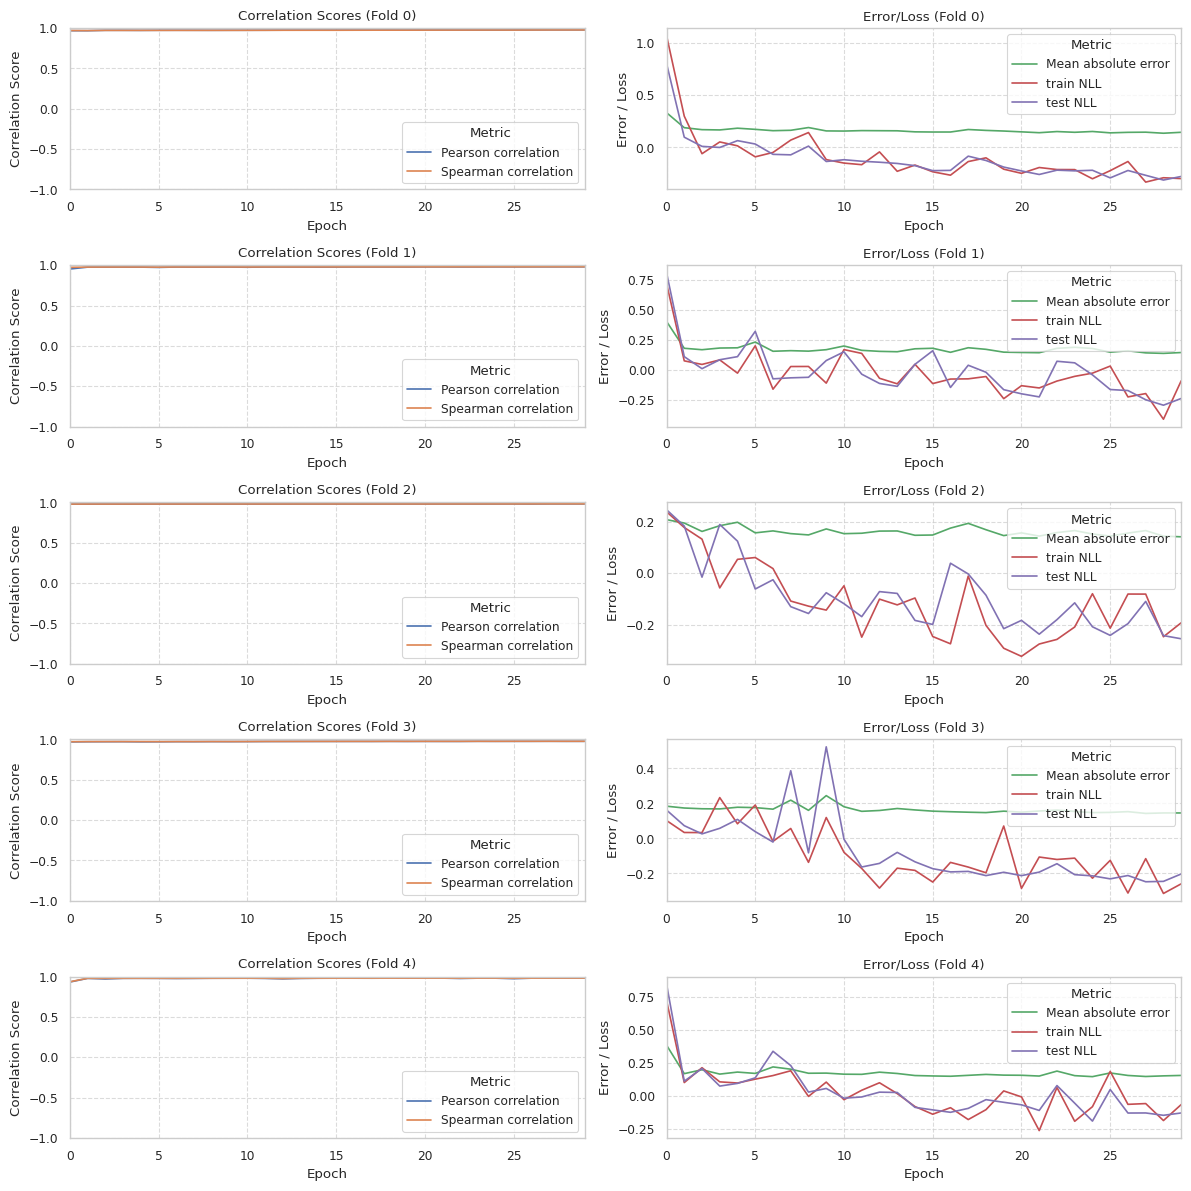

In [ ]:
vis.plot_training_curves(stats)
plt.show()